In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
import networkx as nx
from pyproj import Transformer
import contextily as cx

In [2]:
data_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/centroids_k28_definitivo.csv"

df_full = pd.read_csv(data_path, sep=';')

df_full.head()

,id,species,stage,site,cycle,sex,age,capture_reg,capture_subreg,lon,...,type2,count_ind_sp,weight,wt_sp,wt_dur,wt_sp_sex,wt_ind,wt_ind_sp,next_cluster,cluster
0,100431_1,BLSC,W,W2,1,M,ASY,Southern New England,Rhode Island,-73.892804,...,W,89,1,2.940217,0.279338,5.909524,0.066667,0.000749,15.0,8
1,100431_1,BLSC,S,S1,1,M,ASY,Southern New England,Rhode Island,-62.408619,...,SM,89,1,2.940217,0.095890,5.909524,0.066667,0.000749,19.0,15
2,100431_1,BLSC,M,M1,1,M,ASY,Southern New England,Rhode Island,-80.532833,...,SM,89,1,2.940217,0.271233,5.909524,0.066667,0.000749,19.0,19
3,100431_1,BLSC,M,M2,1,M,ASY,Southern New England,Rhode Island,-79.399203,...,WM,89,1,2.940217,0.076712,5.909524,0.066667,0.000749,8.0,19
4,100431_1,BLSC,W,W1,2,M,ASY,Southern New England,Rhode Island,-70.839910,...,WM,89,1,2.940217,0.010959,5.909524,0.066667,0.000749,7.0,8


Numero di cluster: 21
Grafo BLSC:
  Nodi: 21
  Archi: 105


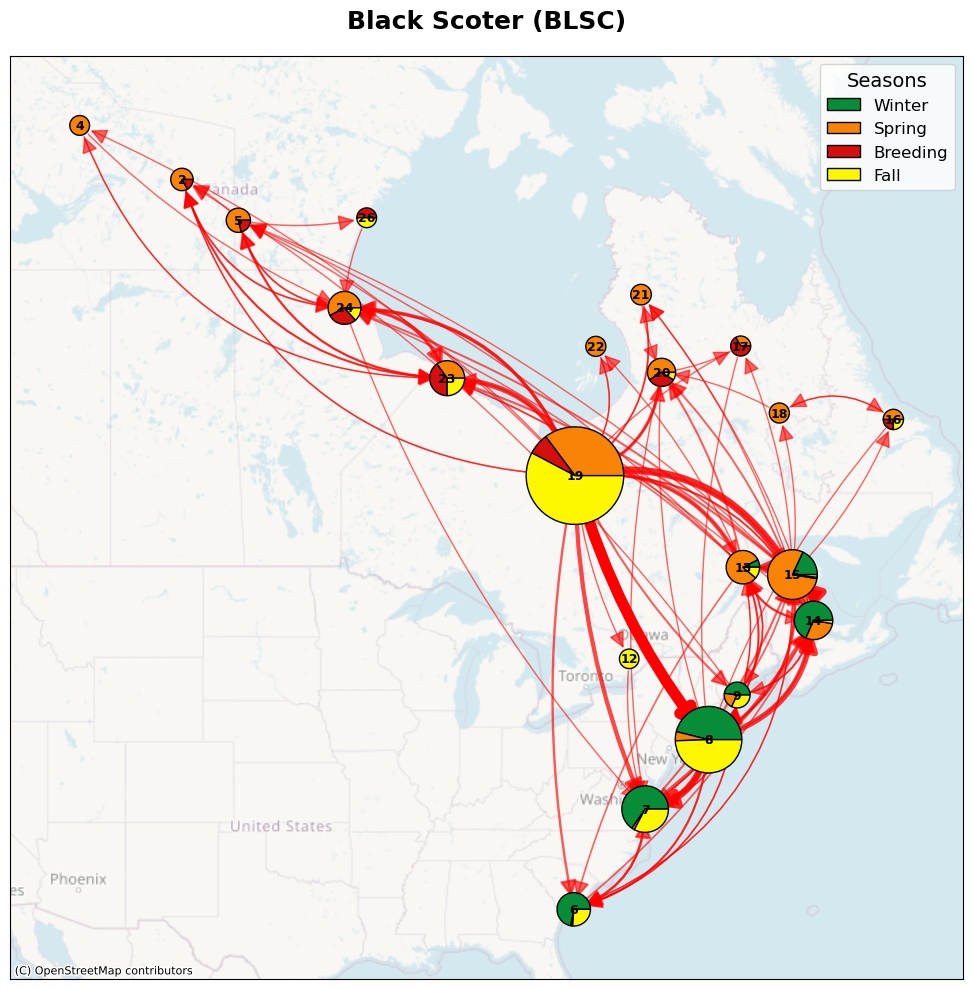

In [3]:
# Filtra solo Black Scoter
df = df_full[df_full['species'] == 'BLSC'].copy()

#Filtra righe con next_cluster valido e rimuovi self-loops
df_valid = df[df['next_cluster'].notna()].copy()
df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
df_valid['cluster'] = df_valid['cluster'].astype(int)

df_links = df_valid[df_valid['cluster'] != df_valid['next_cluster']].copy()

#Cluster coinvolti
clusters_used = sorted(set(df['cluster'].unique()))
print(f"Numero di cluster: {len(clusters_used)}")

edge_weights = df_links.groupby(['cluster', 'next_cluster']).size().reset_index()
edge_weights.columns = ['source', 'target', 'weight']

cluster_weights = df.groupby('cluster').size().reset_index()
cluster_weights.columns = ['cluster', 'total_weight']

#Coordinate dei centroidi (calcolate solo su BLSC)
cluster_coords = df.groupby('cluster')[['lon', 'lat']].mean().reset_index()

cluster_data = cluster_coords.merge(cluster_weights, on='cluster')

season_counts = df.groupby(['cluster', 'from_sea']).size().unstack(fill_value=0)

G = nx.DiGraph()

G.add_nodes_from(clusters_used)

#Archi
for _, row in edge_weights.iterrows():
    G.add_edge(int(row['source']), int(row['target']), weight=row['weight'])

print(f"Grafo BLSC:")
print(f"  Nodi: {G.number_of_nodes()}")
print(f"  Archi: {G.number_of_edges()}")

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

pos = {}
for _, row in cluster_coords.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id in clusters_used:
        x, y = transformer.transform(row['lon'], row['lat'])
        pos[cluster_id] = (x, y)

weights_list = [G[u][v]['weight'] for u, v in G.edges()]
min_weight_link = min(weights_list) if weights_list else 1
max_weight_link = max(weights_list) if weights_list else 1

if max_weight_link > min_weight_link:
    widths = [1.0 + (8 - 1.0) * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
    alphas = [0.6 + 0.4 * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
else:
    widths = [4.0] * len(weights_list)
    alphas = [0.8] * len(weights_list)

min_weight_scatter = cluster_data['total_weight'].min()
max_weight_scatter = cluster_data['total_weight'].max()

season_colors = {
    'W': "#078D38",  #Winter
    'S': "#F88305",  #Spring
    'B': "#D50E0E",  #Breeding
    'F': "#FFF700"   #Fall
}
season_order = ['W', 'S', 'B', 'F']
season_names = {'W': 'Winter', 'S': 'Spring', 'B': 'Breeding', 'F': 'Fall'}

fig, ax = plt.subplots(figsize=(13, 10))

bidirectional_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u):
        bidirectional_edges.add((min(u, v), max(u, v)))

for (u, v), width, alpha in zip(G.edges(), widths, alphas):
    edge_pair = (min(u, v), max(u, v))
    
    if edge_pair in bidirectional_edges:
        rad = 0.35 if u < v else -0.35
        connectionstyle = f'arc3,rad={rad}'
    else:
        connectionstyle = 'arc3,rad=0.1'
    
    nx.draw_networkx_edges(G, pos, 
                           edgelist=[(u, v)], 
                           width=width,
                           alpha=alpha,
                           edge_color='red',
                           arrows=True,
                           arrowsize=25,
                           arrowstyle='-|>',
                           connectionstyle=connectionstyle,
                           ax=ax)

for _, row in cluster_data.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id not in pos:
        continue
        
    x, y = pos[cluster_id]
    
    if cluster_id in season_counts.index:
        counts = season_counts.loc[cluster_id]
        
        sizes = []
        colors = []
        for season in season_order:
            if season in counts.index and counts[season] > 0:
                sizes.append(counts[season])
                colors.append(season_colors[season])
        
        if len(sizes) > 0:
            weight = row['total_weight']
   
            if max_weight_scatter > min_weight_scatter:
                radius = 70000 + (350000 - 70000) * (weight - min_weight_scatter) / (max_weight_scatter - min_weight_scatter)
            else:
                radius = 300000
            
            total = sum(sizes)
            start_angle = 0
            
            for size, color in zip(sizes, colors):
                angle = 360 * size / total
                wedge = Wedge((x, y), radius, start_angle, start_angle + angle,
                             facecolor=color, edgecolor='black', linewidth=1, alpha=1.0)
                ax.add_patch(wedge)
                start_angle += angle
            
            ax.text(x, y, str(cluster_id),
                   fontsize=9, fontweight='bold',
                   ha='center', va='center',
                   color='black', zorder=10)

x_coords = [pos[n][0] for n in pos]
y_coords = [pos[n][1] for n in pos]
ax.set_xlim(min(x_coords) - 500000, max(x_coords) + 500000)
ax.set_ylim(min(y_coords) - 500000, max(y_coords) + 500000)
ax.set_aspect('equal')

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=0)

legend_elements = [mpatches.Patch(facecolor=season_colors[s], edgecolor='black', 
                                   label=season_names[s]) for s in season_order]
ax.legend(handles=legend_elements, title='Seasons', 
          loc='upper right', fontsize=12, title_fontsize=14)

ax.set_title('Black Scoter (BLSC)', 
             fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()

plt.show()

Righe totali BLSC: 588
Individui unici: 42
Numero di cluster: 18
Grafo BLSC maschi:


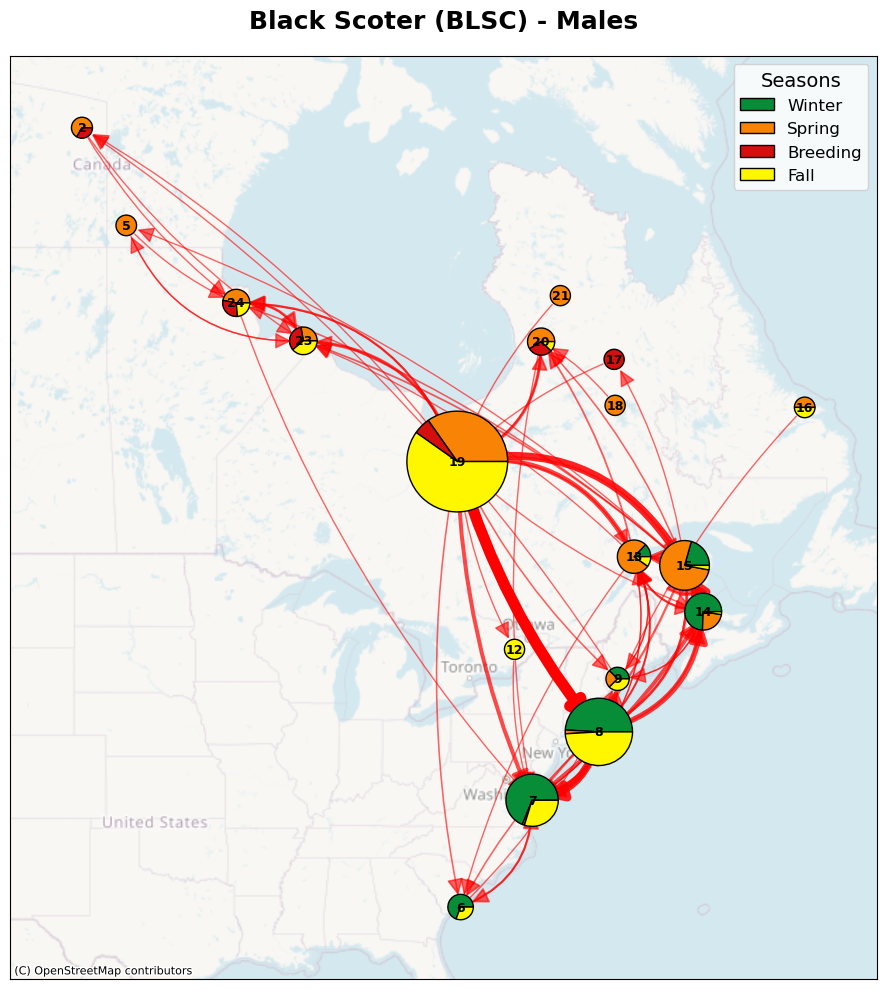

In [5]:
#Filtra solo Black Scoter maschi
df = df_full[(df_full['species'] == 'BLSC') & (df_full['sex'] == 'M')].copy()

print(f"Righe totali BLSC: {len(df)}")
print(f"Individui unici: {df['id'].nunique()}")

#Filtra righe con next_cluster valido e rimuovi self-loops
df_valid = df[df['next_cluster'].notna()].copy()
df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
df_valid['cluster'] = df_valid['cluster'].astype(int)

df_links = df_valid[df_valid['cluster'] != df_valid['next_cluster']].copy()

clusters_used = sorted(set(df['cluster'].unique()))
print(f"Numero di cluster: {len(clusters_used)}")

edge_weights = df_links.groupby(['cluster', 'next_cluster']).size().reset_index()
edge_weights.columns = ['source', 'target', 'weight']

cluster_weights = df.groupby('cluster').size().reset_index()
cluster_weights.columns = ['cluster', 'total_weight']

#Coordinate dei centroidi (calcolate solo su BLSC)
cluster_coords = df.groupby('cluster')[['lon', 'lat']].mean().reset_index()

cluster_data = cluster_coords.merge(cluster_weights, on='cluster')

season_counts = df.groupby(['cluster', 'from_sea']).size().unstack(fill_value=0)

G = nx.DiGraph()

G.add_nodes_from(clusters_used)

#Archi
for _, row in edge_weights.iterrows():
    G.add_edge(int(row['source']), int(row['target']), weight=row['weight'])

print(f"Grafo BLSC maschi:")

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

pos = {}
for _, row in cluster_coords.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id in clusters_used:
        x, y = transformer.transform(row['lon'], row['lat'])
        pos[cluster_id] = (x, y)

weights_list = [G[u][v]['weight'] for u, v in G.edges()]
min_weight_link = min(weights_list) if weights_list else 1
max_weight_link = max(weights_list) if weights_list else 1

if max_weight_link > min_weight_link:
    widths = [1.0 + (8 - 1.0) * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
    alphas = [0.6 + 0.4 * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
else:
    widths = [4.0] * len(weights_list)
    alphas = [0.8] * len(weights_list)

min_weight_scatter = cluster_data['total_weight'].min()
max_weight_scatter = cluster_data['total_weight'].max()

season_colors = {
    'W': "#078D38",  #Winter
    'S': "#F88305",  #Spring
    'B': "#D50E0E",  #Breeding
    'F': "#FFF700"   #Fall
}
season_order = ['W', 'S', 'B', 'F']
season_names = {'W': 'Winter', 'S': 'Spring', 'B': 'Breeding', 'F': 'Fall'}

fig, ax = plt.subplots(figsize=(13, 10))

bidirectional_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u):
        bidirectional_edges.add((min(u, v), max(u, v)))

for (u, v), width, alpha in zip(G.edges(), widths, alphas):
    edge_pair = (min(u, v), max(u, v))
    
    if edge_pair in bidirectional_edges:
        rad = 0.35 if u < v else -0.35
        connectionstyle = f'arc3,rad={rad}'
    else:
        connectionstyle = 'arc3,rad=0.1'
    
    nx.draw_networkx_edges(G, pos, 
                           edgelist=[(u, v)], 
                           width=width,
                           alpha=alpha,
                           edge_color='red',
                           arrows=True,
                           arrowsize=25,
                           arrowstyle='-|>',
                           connectionstyle=connectionstyle,
                           ax=ax)

for _, row in cluster_data.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id not in pos:
        continue
        
    x, y = pos[cluster_id]
    
    if cluster_id in season_counts.index:
        counts = season_counts.loc[cluster_id]
        
        sizes = []
        colors = []
        for season in season_order:
            if season in counts.index and counts[season] > 0:
                sizes.append(counts[season])
                colors.append(season_colors[season])
        
        if len(sizes) > 0:
            weight = row['total_weight']
           
            if max_weight_scatter > min_weight_scatter:
                radius = 70000 + (350000 - 70000) * (weight - min_weight_scatter) / (max_weight_scatter - min_weight_scatter)
            else:
                radius = 300000
            
            total = sum(sizes)
            start_angle = 0
            
            for size, color in zip(sizes, colors):
                angle = 360 * size / total
                wedge = Wedge((x, y), radius, start_angle, start_angle + angle,
                             facecolor=color, edgecolor='black', linewidth=1, alpha=1.0)
                ax.add_patch(wedge)
                start_angle += angle
            
            ax.text(x, y, str(cluster_id),
                   fontsize=9, fontweight='bold',
                   ha='center', va='center',
                   color='black', zorder=10)

x_coords = [pos[n][0] for n in pos]
y_coords = [pos[n][1] for n in pos]
ax.set_xlim(min(x_coords) - 500000, max(x_coords) + 500000)
ax.set_ylim(min(y_coords) - 500000, max(y_coords) + 500000)
ax.set_aspect('equal')

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=0)

legend_elements = [mpatches.Patch(facecolor=season_colors[s], edgecolor='black', 
                                   label=season_names[s]) for s in season_order]
ax.legend(handles=legend_elements, title='Seasons', 
          loc='upper right', fontsize=12, title_fontsize=14)

ax.set_title('Black Scoter (BLSC) - Males', 
             fontsize=18, fontweight='bold', pad=20)


plt.tight_layout()

plt.show()

Righe totali BLSC: 516
Individui unici: 45
Numero di cluster: 20


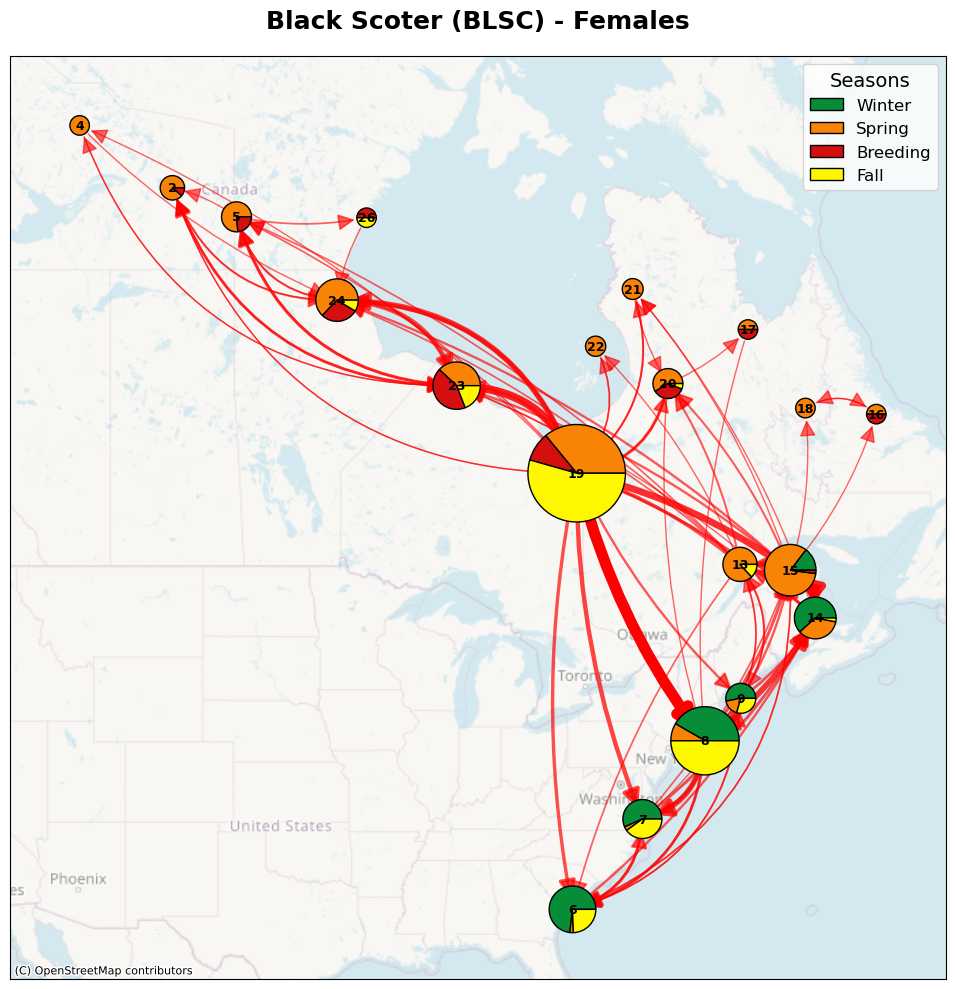

In [6]:
#Filtra solo Black Scoter femmine
df = df_full[(df_full['species'] == 'BLSC') & (df_full['sex'] == 'F')].copy()

print(f"Righe totali BLSC: {len(df)}")
print(f"Individui unici: {df['id'].nunique()}")

df_valid = df[df['next_cluster'].notna()].copy()
df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
df_valid['cluster'] = df_valid['cluster'].astype(int)

df_links = df_valid[df_valid['cluster'] != df_valid['next_cluster']].copy()

clusters_used = sorted(set(df['cluster'].unique()))
print(f"Numero di cluster: {len(clusters_used)}")

edge_weights = df_links.groupby(['cluster', 'next_cluster']).size().reset_index()
edge_weights.columns = ['source', 'target', 'weight']

cluster_weights = df.groupby('cluster').size().reset_index()
cluster_weights.columns = ['cluster', 'total_weight']

#Coordinate dei centroidi (calcolate solo su BLSC)
cluster_coords = df.groupby('cluster')[['lon', 'lat']].mean().reset_index()

cluster_data = cluster_coords.merge(cluster_weights, on='cluster')

season_counts = df.groupby(['cluster', 'from_sea']).size().unstack(fill_value=0)

G = nx.DiGraph()

G.add_nodes_from(clusters_used)

#Archi
for _, row in edge_weights.iterrows():
    G.add_edge(int(row['source']), int(row['target']), weight=row['weight'])

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

pos = {}
for _, row in cluster_coords.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id in clusters_used:
        x, y = transformer.transform(row['lon'], row['lat'])
        pos[cluster_id] = (x, y)

weights_list = [G[u][v]['weight'] for u, v in G.edges()]
min_weight_link = min(weights_list) if weights_list else 1
max_weight_link = max(weights_list) if weights_list else 1

if max_weight_link > min_weight_link:
    widths = [1.0 + (8 - 1.0) * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
    alphas = [0.6 + 0.4 * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
else:
    widths = [4.0] * len(weights_list)
    alphas = [0.8] * len(weights_list)

min_weight_scatter = cluster_data['total_weight'].min()
max_weight_scatter = cluster_data['total_weight'].max()

season_colors = {
    'W': "#078D38",  #Winter
    'S': "#F88305",  #Spring
    'B': "#D50E0E",  #Breeding
    'F': "#FFF700"   #Fall
}
season_order = ['W', 'S', 'B', 'F']
season_names = {'W': 'Winter', 'S': 'Spring', 'B': 'Breeding', 'F': 'Fall'}

fig, ax = plt.subplots(figsize=(13, 10))

bidirectional_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u):
        bidirectional_edges.add((min(u, v), max(u, v)))

for (u, v), width, alpha in zip(G.edges(), widths, alphas):
    edge_pair = (min(u, v), max(u, v))
    
    if edge_pair in bidirectional_edges:
        rad = 0.35 if u < v else -0.35
        connectionstyle = f'arc3,rad={rad}'
    else:
        connectionstyle = 'arc3,rad=0.1'
    
    nx.draw_networkx_edges(G, pos, 
                           edgelist=[(u, v)], 
                           width=width,
                           alpha=alpha,
                           edge_color='red',
                           arrows=True,
                           arrowsize=25,
                           arrowstyle='-|>',
                           connectionstyle=connectionstyle,
                           ax=ax)

for _, row in cluster_data.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id not in pos:
        continue
        
    x, y = pos[cluster_id]
    
    if cluster_id in season_counts.index:
        counts = season_counts.loc[cluster_id]
        
        sizes = []
        colors = []
        for season in season_order:
            if season in counts.index and counts[season] > 0:
                sizes.append(counts[season])
                colors.append(season_colors[season])
        
        if len(sizes) > 0:
            weight = row['total_weight']
        
            if max_weight_scatter > min_weight_scatter:
                radius = 70000 + (350000 - 70000) * (weight - min_weight_scatter) / (max_weight_scatter - min_weight_scatter)
            else:
                radius = 300000
            
            total = sum(sizes)
            start_angle = 0
            
            for size, color in zip(sizes, colors):
                angle = 360 * size / total
                wedge = Wedge((x, y), radius, start_angle, start_angle + angle,
                             facecolor=color, edgecolor='black', linewidth=1, alpha=1.0)
                ax.add_patch(wedge)
                start_angle += angle
            
            ax.text(x, y, str(cluster_id),
                   fontsize=9, fontweight='bold',
                   ha='center', va='center',
                   color='black', zorder=10)

x_coords = [pos[n][0] for n in pos]
y_coords = [pos[n][1] for n in pos]
ax.set_xlim(min(x_coords) - 500000, max(x_coords) + 500000)
ax.set_ylim(min(y_coords) - 500000, max(y_coords) + 500000)
ax.set_aspect('equal')

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=0)

legend_elements = [mpatches.Patch(facecolor=season_colors[s], edgecolor='black', 
                                   label=season_names[s]) for s in season_order]
ax.legend(handles=legend_elements, title='Seasons', 
          loc='upper right', fontsize=12, title_fontsize=14)

ax.set_title('Black Scoter (BLSC) - Females', 
             fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()

plt.show()